In [34]:
import base64
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial.distance import cosine, euclidean
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [35]:
# Load the dataset
gdf = gpd.read_file('../dimension-reduction/data/5000_sampled_classified_embeddings.geojson')

# Decode embeddings from base64
gdf['embedding'] = gdf['embedding'].apply(lambda v: json.loads(base64.b64decode(v)))

print(f"Total samples: {len(gdf)}")
print(f"Columns: {gdf.columns.tolist()}")

Total samples: 5000
Columns: ['lat', 'lon', 'classification', 'embedding', 'umap_1d_x', 'umap_2d_x', 'umap_2d_y', 'umap_3d_x', 'umap_3d_y', 'umap_3d_z', 'tsne_1d_x', 'tsne_2d_x', 'tsne_2d_y', 'tsne_3d_x', 'tsne_3d_y', 'tsne_3d_z', 'index_right', 'NAME', 'ISO_A3', 'SUBREGION', 'CONTINENT', 'subregion_code', 'subregion_name', 'SOV_A3', 'geometry']


## Step 1: Analyze Two Anomalous Pairs

We'll examine two extreme cases that demonstrate how satellite embeddings can diverge from geographic distance:
1. **Far but Similar**: Two locations thousands of km apart with nearly identical satellite embeddings
2. **Near but Different**: Two locations nearby with very different embeddings

In [36]:
from scipy.spatial.distance import cdist
from geopy.distance import geodesic

# Hard-code the two anomalous pairs

# Distance: 10,462 km, Similarity: 0.8617
# Location 1: (-0.5579, 23.4778)
# Location 2: (-5.8461, -70.5832)
# Region 1: Middle Africa (112)
# Region 2: South America (112)


anomalous_pairs = {
    'far_similar': {
        'loc1': {'lat': -0.5579, 'lon': 23.4778},
        'loc2': {'lat': -5.8461, 'lon': -70.5832}
    },
    'near_different': {
        'loc1': {'lat': 22.9205, 'lon': 58.3107},
        'loc2': {'lat': 22.1136, 'lon': 58.6672}
    }
}

print("Loading hard-coded anomalous pairs...")
print("\nPair 1 (Far but Similar):")
print(f"  Location 1: ({anomalous_pairs['far_similar']['loc1']['lat']:.4f}, {anomalous_pairs['far_similar']['loc1']['lon']:.4f})")
print(f"  Location 2: ({anomalous_pairs['far_similar']['loc2']['lat']:.4f}, {anomalous_pairs['far_similar']['loc2']['lon']:.4f})")
print("\nPair 2 (Near but Different):")
print(f"  Location 1: ({anomalous_pairs['near_different']['loc1']['lat']:.4f}, {anomalous_pairs['near_different']['loc1']['lon']:.4f})")
print(f"  Location 2: ({anomalous_pairs['near_different']['loc2']['lat']:.4f}, {anomalous_pairs['near_different']['loc2']['lon']:.4f})")

Loading hard-coded anomalous pairs...

Pair 1 (Far but Similar):
  Location 1: (-0.5579, 23.4778)
  Location 2: (-5.8461, -70.5832)

Pair 2 (Near but Different):
  Location 1: (22.9205, 58.3107)
  Location 2: (22.1136, 58.6672)


In [37]:
# Find these locations in the dataset
print("\nSearching for locations in dataset...")
tolerance = 0.01

locations = []
for pair_name, pair_data in anomalous_pairs.items():
    for loc_name, loc_coords in pair_data.items():
        matches = gdf[
            (gdf['lat'].between(loc_coords['lat'] - tolerance, loc_coords['lat'] + tolerance)) &
            (gdf['lon'].between(loc_coords['lon'] - tolerance, loc_coords['lon'] + tolerance))
        ]
        if len(matches) > 0:
            locations.append(matches.iloc[0])
            print(f"Found {pair_name} {loc_name}: ({matches.iloc[0]['lat']:.4f}, {matches.iloc[0]['lon']:.4f})")
        else:
            print(f"WARNING: {pair_name} {loc_name} not found in dataset!")

if len(locations) == 4:
    # Extract data for the four locations
    far_similar_1, far_similar_2, near_different_1, near_different_2 = locations
    
    # Calculate distances and similarities
    emb_fs1 = np.array(far_similar_1['embedding'])
    emb_fs2 = np.array(far_similar_2['embedding'])
    emb_nd1 = np.array(near_different_1['embedding'])
    emb_nd2 = np.array(near_different_2['embedding'])
    
    dist_far = geodesic((far_similar_1['lat'], far_similar_1['lon']), 
                        (far_similar_2['lat'], far_similar_2['lon'])).kilometers
    sim_far = 1 - cosine(emb_fs1, emb_fs2)
    
    dist_near = geodesic((near_different_1['lat'], near_different_1['lon']), 
                         (near_different_2['lat'], near_different_2['lon'])).kilometers
    sim_near = 1 - cosine(emb_nd1, emb_nd2)
    
    print(f"\nFar but Similar pair: {dist_far:.1f} km apart, similarity: {sim_far:.6f}")
    print(f"Near but Different pair: {dist_near:.1f} km apart, similarity: {sim_near:.6f}")
else:
    print(f"\nERROR: Only found {len(locations)}/4 locations in dataset!")


Searching for locations in dataset...
Found far_similar loc1: (-0.5579, 23.4778)
Found far_similar loc2: (-5.8461, -70.5832)
Found near_different loc1: (22.9205, 58.3107)
Found near_different loc2: (22.1136, 58.6672)

Far but Similar pair: 10462.0 km apart, similarity: 0.861734
Near but Different pair: 96.6 km apart, similarity: -0.043642


In [38]:
# Visualize the two anomalous pairs
print("\n" + "="*80)
print("Anomalous Pairs Summary")
print("="*80)

print("\nANOMALY 1: FAR but SIMILAR")
print("="*60)
print(f"Location 1: ({far_similar_1['lat']:.4f}, {far_similar_1['lon']:.4f})")
print(f"  Classification: {far_similar_1['classification']}")
print(f"  Region: {far_similar_1['subregion_name']}")
print(f"Location 2: ({far_similar_2['lat']:.4f}, {far_similar_2['lon']:.4f})")
print(f"  Classification: {far_similar_2['classification']}")
print(f"  Region: {far_similar_2['subregion_name']}")
print(f"Geographic Distance: {dist_far:.1f} km")
print(f"Embedding Similarity: {sim_far:.6f}")
print(f"\nInterpretation: Despite being {dist_far:.0f}km apart, these locations")
print(f"   have nearly identical satellite signatures (similarity: {sim_far:.4f}).")
print(f"   This suggests similar land cover, vegetation, or climate patterns.")

print("\n\nANOMALY 2: NEAR but DIFFERENT")
print("="*60)
print(f"Location 1: ({near_different_1['lat']:.4f}, {near_different_1['lon']:.4f})")
print(f"  Classification: {near_different_1['classification']}")
print(f"  Region: {near_different_1['subregion_name']}")
print(f"Location 2: ({near_different_2['lat']:.4f}, {near_different_2['lon']:.4f})")
print(f"  Classification: {near_different_2['classification']}")
print(f"  Region: {near_different_2['subregion_name']}")
print(f"Geographic Distance: {dist_near:.1f} km")
print(f"Embedding Similarity: {sim_near:.6f}")
print(f"\nInterpretation: Despite being only {dist_near:.1f}km apart, these locations")
print(f"   have very different satellite signatures (similarity: {sim_near:.4f}).")
print(f"   This suggests a sharp boundary: urban/rural, water/land, or elevation change.")


Anomalous Pairs Summary

ANOMALY 1: FAR but SIMILAR
Location 1: (-0.5579, 23.4778)
  Classification: 112
  Region: Middle Africa
Location 2: (-5.8461, -70.5832)
  Classification: 112
  Region: South America
Geographic Distance: 10462.0 km
Embedding Similarity: 0.861734

Interpretation: Despite being 10462km apart, these locations
   have nearly identical satellite signatures (similarity: 0.8617).
   This suggests similar land cover, vegetation, or climate patterns.


ANOMALY 2: NEAR but DIFFERENT
Location 1: (22.9205, 58.3107)
  Classification: 0
  Region: Western Asia
Location 2: (22.1136, 58.6672)
  Classification: 0
  Region: Western Asia
Geographic Distance: 96.6 km
Embedding Similarity: -0.043642

Interpretation: Despite being only 96.6km apart, these locations
   have very different satellite signatures (similarity: -0.0436).
   This suggests a sharp boundary: urban/rural, water/land, or elevation change.


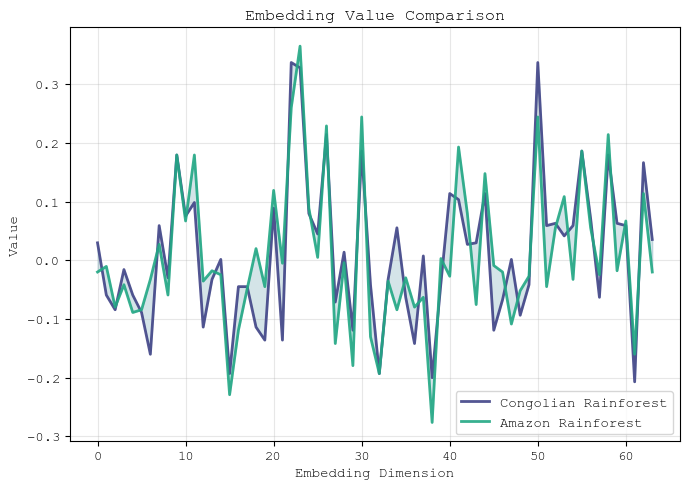

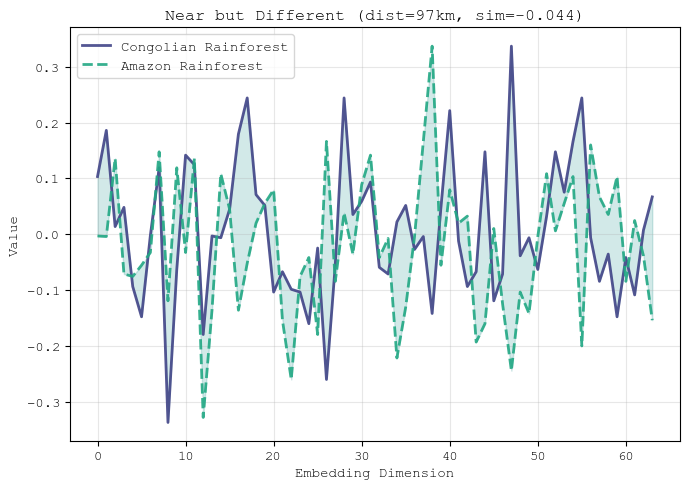


Key observations:
   - The FAR pair has embeddings that track closely across dimensions
   - The NEAR pair shows large divergences in multiple embedding dimensions
   - This explains why geography does not equal embedding similarity in these edge cases


In [58]:
# Visualize the embedding differences
# Set font to Courier New
plt.rcParams['font.family'] = 'Courier New'

# Use viridis colormap for the lines
viridis = plt.cm.viridis

# Plot 1: Far but Similar
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))
x = np.arange(64)
ax1.plot(x, emb_fs1, color=viridis(0.2), alpha=0.9, label='Congolian Rainforest', linewidth=2)
ax1.plot(x, emb_fs2, color=viridis(0.6), alpha=0.9, label='Amazon Rainforest', linewidth=2)
ax1.fill_between(x, emb_fs1, emb_fs2, alpha=0.2, color=viridis(0.4))
ax1.set_xlabel('Embedding Dimension')
ax1.set_ylabel('Value')
ax1.set_title(f'Embedding Value Comparison')
# ax1.set_title(f'Far but Similar (dist={dist_far:.0f}km, sim={sim_far:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embeddings_comparison_far_similar.png', dpi=150)
plt.show()

# Plot 2: Near but Different
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))
ax2.plot(x, emb_nd1, color=viridis(0.2), alpha=0.9, label='Congolian Rainforest', linewidth=2)
ax2.plot(x, emb_nd2, color=viridis(0.6), alpha=0.9, label='Amazon Rainforest', linewidth=2, linestyle='--')
ax2.fill_between(x, emb_nd1, emb_nd2, alpha=0.2, color=viridis(0.5))
ax2.set_xlabel('Embedding Dimension')
ax2.set_ylabel('Value')
ax2.set_title(f'Near but Different (dist={dist_near:.0f}km, sim={sim_near:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embeddings_comparison_near_different.png', dpi=150)
plt.show()

print("\nKey observations:")
print("   - The FAR pair has embeddings that track closely across dimensions")
print("   - The NEAR pair shows large divergences in multiple embedding dimensions")
print("   - This explains why geography does not equal embedding similarity in these edge cases")


Overall Pattern: Geographic vs Embedding Distance

Sampling 1000 locations from 5000 total locations...
Computing pairwise distances and similarities...
From 499,500 possible pairs, plotting 5,000 randomly selected pairs...

Correlation between geographic distance and embedding similarity: -0.4255
(Negative correlation expected: more distant = less similar)


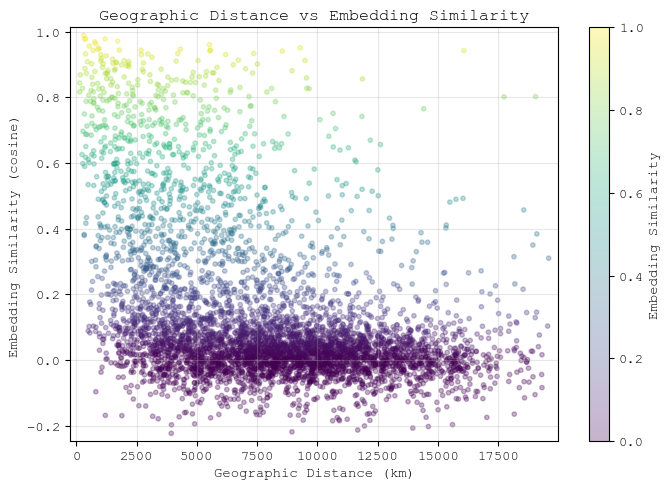


Data range - Geographic Distance: 135 to 19589 km
Data range - Embedding Similarity: -0.2233 to 0.9885


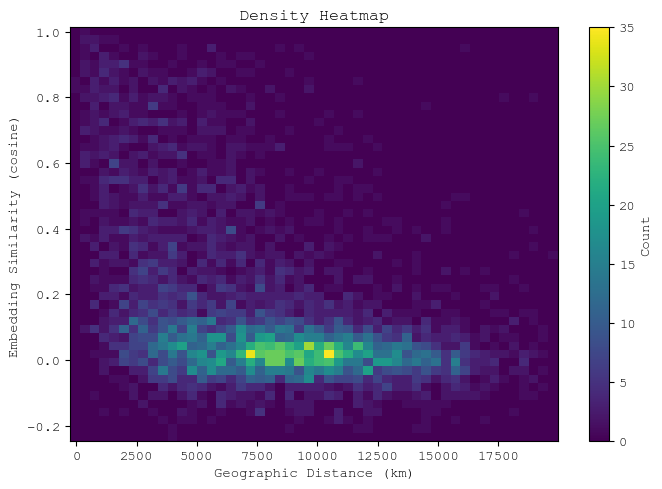


Key insights:
- 2 pairs are >2000km apart yet >0.95 similar
- 0 pairs are <100km apart yet <0.8 similar


In [45]:
# Create overall pattern visualization with many pairs
# Set font to Courier New for all plots
plt.rcParams['font.family'] = 'Courier New'

print("\n" + "="*80)
print("Overall Pattern: Geographic vs Embedding Distance")
print("="*80)

# Sample a subset of the full dataset for visualization
# We use 1000 random locations from the 5000 available in the dataset
# This gives us up to 499,500 possible pairs (1000 choose 2)
np.random.seed(42)
sample_size = 1000  # Number of locations to sample
sample_indices = np.random.choice(len(gdf), sample_size, replace=False)

print(f"\nSampling {sample_size} locations from {len(gdf)} total locations...")

# Extract embeddings and coordinates for these sampled locations
sampled_embeddings = np.array([np.array(gdf.iloc[i]['embedding']) for i in sample_indices])
sampled_coords = gdf.iloc[sample_indices][['lat', 'lon']].values

# Calculate pairwise distances and similarities
# From 1000 locations, we can form 499,500 unique pairs
# We'll randomly sample 5000 of these pairs to plot (for computational efficiency)
print("Computing pairwise distances and similarities...")
viz_sample_size = 5000  # Number of pairs to actually plot
upper_tri_indices = np.triu_indices(sample_size, k=1)  # All unique pairs (upper triangle of matrix)
num_pairs = len(upper_tri_indices[0])  # Total: 499,500 pairs
viz_indices = np.random.choice(num_pairs, min(viz_sample_size, num_pairs), replace=False)

print(f"From {num_pairs:,} possible pairs, plotting {len(viz_indices):,} randomly selected pairs...")

geo_distances_viz = []
emb_similarities_viz = []

for idx in viz_indices:
    i = upper_tri_indices[0][idx]
    j = upper_tri_indices[1][idx]
    
    # Geographic distance
    dist_km = geodesic(sampled_coords[i], sampled_coords[j]).kilometers
    geo_distances_viz.append(dist_km)
    
    # Embedding similarity
    sim = 1 - cosine(sampled_embeddings[i], sampled_embeddings[j])
    emb_similarities_viz.append(sim)

geo_dist_sample = np.array(geo_distances_viz)
emb_sim_sample = np.array(emb_similarities_viz)

# Calculate correlation
correlation = np.corrcoef(geo_dist_sample, emb_sim_sample)[0, 1]
print(f"\nCorrelation between geographic distance and embedding similarity: {correlation:.4f}")
print("(Negative correlation expected: more distant = less similar)")

# Calculate axis limits from data
x_min, x_max = geo_dist_sample.min(), geo_dist_sample.max()
y_min, y_max = emb_sim_sample.min(), emb_sim_sample.max()

# Add small padding
x_padding = (x_max - x_min) * 0.02
y_padding = (y_max - y_min) * 0.02

# Plot 1: Scatter plot
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))
scatter = ax1.scatter(geo_dist_sample, emb_sim_sample, alpha=0.3, s=10, c=emb_sim_sample, 
                     cmap='viridis', vmin=0, vmax=1)
ax1.set_xlabel('Geographic Distance (km)')
ax1.set_ylabel('Embedding Similarity (cosine)')
ax1.set_title('Geographic Distance vs Embedding Similarity')
ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Embedding Similarity')
plt.tight_layout()
plt.savefig('geographic_vs_embedding_distance_scatter.png', dpi=150)
plt.show()

# Plot 2: 2D histogram (heatmap) with matching axes
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))
h, xedges, yedges = np.histogram2d(geo_dist_sample, emb_sim_sample, bins=50, 
                                     range=[[x_min - x_padding, x_max + x_padding], 
                                            [y_min - y_padding, y_max + y_padding]])
extent = [x_min - x_padding, x_max + x_padding, y_min - y_padding, y_max + y_padding]
im = ax2.imshow(h.T, origin='lower', aspect='auto', extent=extent, cmap='viridis', interpolation='nearest')
ax2.set_xlabel('Geographic Distance (km)')
ax2.set_ylabel('Embedding Similarity (cosine)')
ax2.set_title('Density Heatmap')
ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
plt.colorbar(im, ax=ax2, label='Count')

print(f"\nData range - Geographic Distance: {x_min:.0f} to {x_max:.0f} km")
print(f"Data range - Embedding Similarity: {y_min:.4f} to {y_max:.4f}")

plt.tight_layout()
plt.savefig('geographic_vs_embedding_distance_heatmap.png', dpi=150)
plt.show()

print("\nKey insights:")
print(f"- {np.sum((geo_dist_sample > 2000) & (emb_sim_sample > 0.95))} pairs are >2000km apart yet >0.95 similar")
print(f"- {np.sum((geo_dist_sample < 100) & (emb_sim_sample < 0.8))} pairs are <100km apart yet <0.8 similar")


Visualization with Anomalies Highlighted


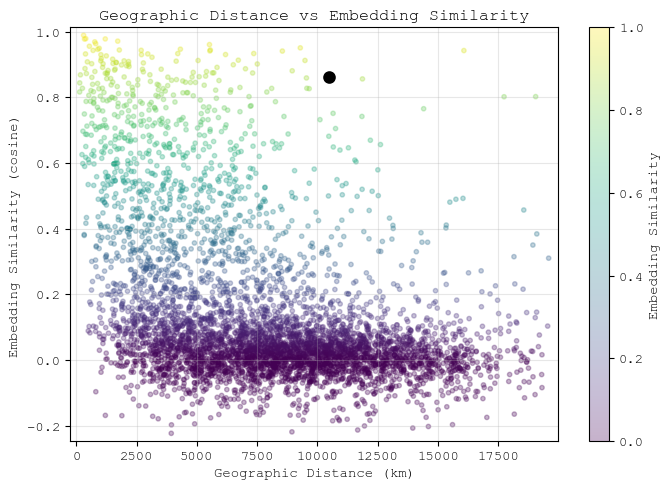

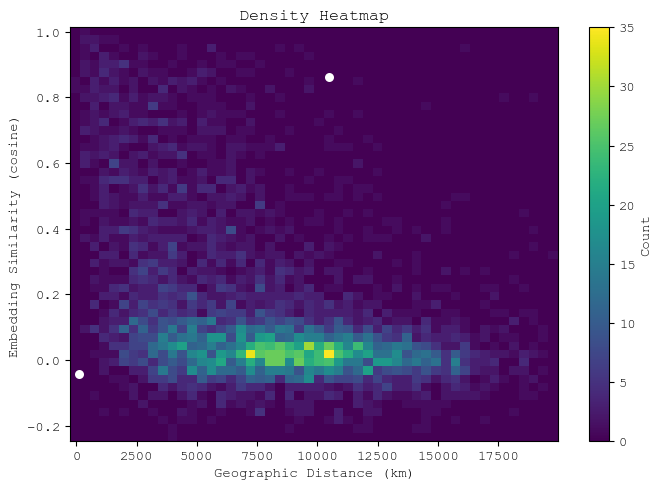


Saved visualizations with highlighted anomalies
Files: geographic_vs_embedding_distance_scatter_with_anomalies.png
       geographic_vs_embedding_distance_heatmap_with_anomalies.png


In [59]:
# Visualize with anomalies highlighted
print("\n" + "="*80)
print("Visualization with Anomalies Highlighted")
print("="*80)

# Plot 1: Scatter plot with highlighted anomalies
fig1, ax1 = plt.subplots(1, 1, figsize=(7, 5))
scatter = ax1.scatter(geo_dist_sample, emb_sim_sample, alpha=0.3, s=10, c=emb_sim_sample, 
                     cmap='viridis', vmin=0, vmax=1, zorder=1)
ax1.set_xlabel('Geographic Distance (km)')
ax1.set_ylabel('Embedding Similarity (cosine)')
ax1.set_title('Geographic Distance vs Embedding Similarity')
ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Embedding Similarity')

# Highlight anomalies with black dots
ax1.scatter(dist_far, sim_far, s=50, c='black', marker='o', 
           edgecolors='black', linewidths=2, zorder=3)
# ax1.scatter(dist_near, sim_near, s=20, c='black', marker='o', 
#            edgecolors='black', linewidths=2, zorder=3)

plt.tight_layout()
plt.savefig('geographic_vs_embedding_distance_scatter_with_anomalies.png', dpi=150)
plt.show()

# Plot 2: 2D histogram (heatmap) with matching axes and anomalies
fig2, ax2 = plt.subplots(1, 1, figsize=(7, 5))
h, xedges, yedges = np.histogram2d(geo_dist_sample, emb_sim_sample, bins=50,
                                     range=[[x_min - x_padding, x_max + x_padding], 
                                            [y_min - y_padding, y_max + y_padding]])
extent = [x_min - x_padding, x_max + x_padding, y_min - y_padding, y_max + y_padding]
im = ax2.imshow(h.T, origin='lower', aspect='auto', extent=extent, cmap='viridis', interpolation='nearest')
ax2.set_xlabel('Geographic Distance (km)')
ax2.set_ylabel('Embedding Similarity (cosine)')
ax2.set_title('Density Heatmap')
ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
plt.colorbar(im, ax=ax2, label='Count')

# Highlight anomalies with white dots on heatmap
ax2.scatter(dist_far, sim_far, s=20, c='white', marker='o', 
           edgecolors='white', linewidths=2, zorder=3)
ax2.scatter(dist_near, sim_near, s=20, c='white', marker='o', 
           edgecolors='white', linewidths=2, zorder=3)

plt.tight_layout()
plt.savefig('geographic_vs_embedding_distance_heatmap_with_anomalies.png', dpi=150)
plt.show()

print("\nSaved visualizations with highlighted anomalies")
print("Files: geographic_vs_embedding_distance_scatter_with_anomalies.png")
print("       geographic_vs_embedding_distance_heatmap_with_anomalies.png")

In [ ]:
# Deep dive into the two anomalous pairs
print("\n" + "="*80)
print("Deep Dive: Comparing the Two Anomalous Pairs")
print("="*80)

# Pair 1: Far but Similar
print("\n" + "="*60)
print("PAIR 1: FAR BUT SIMILAR")
print("="*60)
print(f"\nGeographic Distance: {dist_far:.1f} km")
print(f"Embedding Similarity: {sim_far:.6f}")

print("\nLocation 1:")
print(f"  Coordinates: ({far_similar_1['lat']:.4f}, {far_similar_1['lon']:.4f})")
print(f"  Classification: {far_similar_1['classification']}")
print(f"  Region: {far_similar_1['subregion_name']}")

print("\nLocation 2:")
print(f"  Coordinates: ({far_similar_2['lat']:.4f}, {far_similar_2['lon']:.4f})")
print(f"  Classification: {far_similar_2['classification']}")
print(f"  Region: {far_similar_2['subregion_name']}")

# Embedding statistics for far pair
print("\nEmbedding Statistics:")
print(f"  Location 1 - Mean: {emb_fs1.mean():.4f}, Std: {emb_fs1.std():.4f}, L2 norm: {np.linalg.norm(emb_fs1):.4f}")
print(f"  Location 2 - Mean: {emb_fs2.mean():.4f}, Std: {emb_fs2.std():.4f}, L2 norm: {np.linalg.norm(emb_fs2):.4f}")

diff_far = np.abs(emb_fs1 - emb_fs2)
print(f"\nPer-dimension difference:")
print(f"  Mean: {diff_far.mean():.4f}")
print(f"  Max: {diff_far.max():.4f}")
print(f"  Median: {np.median(diff_far):.4f}")

# Find most different and most similar dimensions
top_diff_far = np.argsort(diff_far)[-5:][::-1]
top_sim_far = np.argsort(diff_far)[:5]

print(f"\nMost DIFFERENT dimensions:")
for idx in top_diff_far:
    print(f"  Dimension {idx:02d}: Loc1={emb_fs1[idx]:.4f}, Loc2={emb_fs2[idx]:.4f}, diff={diff_far[idx]:.4f}")

print(f"\nMost SIMILAR dimensions:")
for idx in top_sim_far:
    print(f"  Dimension {idx:02d}: Loc1={emb_fs1[idx]:.4f}, Loc2={emb_fs2[idx]:.4f}, diff={diff_far[idx]:.4f}")

print(f"\n\nInterpretation: These locations are {dist_far:.0f}km apart (spanning different continents)")
print(f"yet have {sim_far:.4f} similarity. This indicates they share very similar visual")
print(f"characteristics from satellite imagery - likely similar climate, vegetation, or land cover.")

# Pair 2: Near but Different
print("\n\n" + "="*60)
print("PAIR 2: NEAR BUT DIFFERENT")
print("="*60)
print(f"\nGeographic Distance: {dist_near:.1f} km")
print(f"Embedding Similarity: {sim_near:.6f}")

print("\nLocation 1:")
print(f"  Coordinates: ({near_different_1['lat']:.4f}, {near_different_1['lon']:.4f})")
print(f"  Classification: {near_different_1['classification']}")
print(f"  Region: {near_different_1['subregion_name']}")

print("\nLocation 2:")
print(f"  Coordinates: ({near_different_2['lat']:.4f}, {near_different_2['lon']:.4f})")
print(f"  Classification: {near_different_2['classification']}")
print(f"  Region: {near_different_2['subregion_name']}")

# Embedding statistics for near pair
print("\nEmbedding Statistics:")
print(f"  Location 1 - Mean: {emb_nd1.mean():.4f}, Std: {emb_nd1.std():.4f}, L2 norm: {np.linalg.norm(emb_nd1):.4f}")
print(f"  Location 2 - Mean: {emb_nd2.mean():.4f}, Std: {emb_nd2.std():.4f}, L2 norm: {np.linalg.norm(emb_nd2):.4f}")

diff_near = np.abs(emb_nd1 - emb_nd2)
print(f"\nPer-dimension difference:")
print(f"  Mean: {diff_near.mean():.4f}")
print(f"  Max: {diff_near.max():.4f}")
print(f"  Median: {np.median(diff_near):.4f}")

# Find most different and most similar dimensions
top_diff_near = np.argsort(diff_near)[-5:][::-1]
top_sim_near = np.argsort(diff_near)[:5]

print(f"\nMost DIFFERENT dimensions:")
for idx in top_diff_near:
    print(f"  Dimension {idx:02d}: Loc1={emb_nd1[idx]:.4f}, Loc2={emb_nd2[idx]:.4f}, diff={diff_near[idx]:.4f}")

print(f"\nMost SIMILAR dimensions:")
for idx in top_sim_near:
    print(f"  Dimension {idx:02d}: Loc1={emb_nd1[idx]:.4f}, Loc2={emb_nd2[idx]:.4f}, diff={diff_near[idx]:.4f}")

print(f"\n\nInterpretation: These locations are only {dist_near:.0f}km apart (same region)")
print(f"yet have {sim_near:.4f} similarity (negative = opposite characteristics).")
print(f"This suggests a sharp boundary or transition - possibly coastal/inland, urban/rural,")
print(f"or different land cover types like desert/vegetation.")

# Comparison
print("\n\n" + "="*60)
print("COMPARISON")
print("="*60)
print(f"\nThe FAR pair has {diff_far.mean():.4f} mean difference across dimensions")
print(f"The NEAR pair has {diff_near.mean():.4f} mean difference across dimensions")
print(f"\nRatio: The NEAR pair's embeddings differ {diff_near.mean() / diff_far.mean():.1f}x more on average")
print(f"despite being {dist_far / dist_near:.0f}x closer geographically!")


Deep Dive: Comparing the Two Anomalous Pairs

PAIR 1: FAR BUT SIMILAR

Geographic Distance: 10462.0 km
Embedding Similarity: 0.861734

Location 1:
  Coordinates: (-0.5579, 23.4778)
  Classification: 112
  Region: Middle Africa

Location 2:
  Coordinates: (-5.8461, -70.5832)
  Classification: 112
  Region: South America

Embedding Statistics:
  Location 1 - Mean: 0.0110, Std: 0.1245, L2 norm: 1.0000
  Location 2 - Mean: 0.0074, Std: 0.1248, L2 norm: 1.0005

Per-dimension difference:
  Mean: 0.0531
  Max: 0.1409
  Median: 0.0470

Most DIFFERENT dimensions:
  Dimension 40: Loc1=0.1137, Loc2=-0.0271, diff=0.1409
  Dimension 34: Loc1=0.0554, Loc2=-0.0842, diff=0.1396
  Dimension 18: Loc1=-0.1137, Loc2=0.0199, diff=0.1337
  Dimension 21: Loc1=-0.1359, Loc2=-0.0050, diff=0.1309
  Dimension 06: Loc1=-0.1600, Loc2=-0.0325, diff=0.1275

Most SIMILAR dimensions:
  Dimension 32: Loc1=-0.1929, Loc2=-0.1929, diff=0.0000
  Dimension 09: Loc1=0.1794, Loc2=0.1794, diff=0.0000
  Dimension 55: Loc1=0.18

In [ ]:
# Find additional examples of far but similar pairs
# Search through our sampled pairs to find more examples

print("Searching for additional Far-but-Similar pairs...")
print("="*80)

# Define thresholds for "far but similar"
distance_threshold = 10000  # At least 10,000 km apart
similarity_threshold = 0.7  # At least 0.7 cosine similarity

# Sample a subset of pairs to search through (reusing sampled data from above)
# We already have: sampled_coords, sampled_embeddings from the visualization

# Calculate all pairwise distances and similarities for the sampled locations
far_similar_examples = []

# Search through a sample of pairs
search_sample_size = 3000  # Check 3000 random pairs
search_indices = np.random.choice(len(upper_tri_indices[0]), size=min(search_sample_size, len(upper_tri_indices[0])), replace=False)

for idx in search_indices:
    i = upper_tri_indices[0][idx]
    j = upper_tri_indices[1][idx]
    
    coord1 = sampled_coords[i]
    coord2 = sampled_coords[j]
    emb1 = sampled_embeddings[i]
    emb2 = sampled_embeddings[j]
    
    # Calculate geographic distance
    dist_km = geodesic(coord1, coord2).kilometers
    
    # Calculate embedding similarity
    sim = 1 - cosine(emb1, emb2)
    
    # Check if this is a far-but-similar pair
    if dist_km >= distance_threshold and sim >= similarity_threshold:
        far_similar_examples.append({
            'coord1': coord1,
            'coord2': coord2,
            'distance_km': dist_km,
            'similarity': sim,
            'idx1': i,
            'idx2': j
        })

# Sort by similarity (highest first)
far_similar_examples = sorted(far_similar_examples, key=lambda x: x['similarity'], reverse=True)

print(f"\nFound {len(far_similar_examples)} far-but-similar pairs")
print(f"(Distance >= {distance_threshold} km, Similarity >= {similarity_threshold})\n")

# Display top 5 examples
num_to_show = min(5, len(far_similar_examples))
print(f"Top {num_to_show} examples:\n")

for i, example in enumerate(far_similar_examples[:num_to_show], 1):
    print(f"\n{i}. Distance: {example['distance_km']:,.0f} km, Similarity: {example['similarity']:.4f}")
    print(f"   Location 1: ({example['coord1'][0]:.4f}, {example['coord1'][1]:.4f})")
    print(f"   Location 2: ({example['coord2'][0]:.4f}, {example['coord2'][1]:.4f})")
    
    # Look up the actual location data from gdf
    # idx1 and idx2 are indices into sampled_coords, need to map back to gdf
    idx1, idx2 = example['idx1'], example['idx2']
    gdf_idx1 = sample_indices[idx1]
    gdf_idx2 = sample_indices[idx2]
    loc1 = gdf.iloc[gdf_idx1]
    loc2 = gdf.iloc[gdf_idx2]
    
    print(f"   Region 1: {loc1['subregion_name']} ({loc1['classification']})")
    print(f"   Region 2: {loc2['subregion_name']} ({loc2['classification']})")

print("\n" + "="*80)

Searching for additional Far-but-Similar pairs...

Found 10 far-but-similar pairs
(Distance >= 10000 km, Similarity >= 0.7)

Top 5 examples:


1. Distance: 12,028 km, Similarity: 0.9297
   Location 1: (37.7012, 1.4515)
   Location 2: (9.5885, 123.2969)
   Region 1: Unknown (0)
   Region 2: South-Eastern Asia (0)

2. Distance: 15,881 km, Similarity: 0.8814
   Location 1: (35.2291, 27.8964)
   Location 2: (-22.5354, 167.5653)
   Region 1: Unknown (0)
   Region 2: Unknown (0)

3. Distance: 17,004 km, Similarity: 0.8806
   Location 1: (-37.3672, 176.2496)
   Location 2: (46.2361, 30.9022)
   Region 1: Unknown (0)
   Region 2: Unknown (0)

4. Distance: 13,980 km, Similarity: 0.8627
   Location 1: (-21.1322, 151.6525)
   Location 2: (44.1737, 31.8175)
   Region 1: Unknown (0)
   Region 2: Unknown (0)

5. Distance: 11,722 km, Similarity: 0.8384
   Location 1: (10.1815, -71.8383)
   Location 2: (-1.0396, 33.5308)
   Region 1: South America (0)
   Region 2: Eastern Africa (0)



### About the Similarity Range

**Why is cosine similarity in the range ~-0.2 to 1.0?**

Theoretically, cosine similarity ranges from **-1 to +1**:
- **+1**: Vectors point in exactly the same direction (identical)
- **0**: Vectors are orthogonal (completely independent)
- **-1**: Vectors point in opposite directions (perfectly opposite)

In our satellite embeddings, we observe a range of approximately **-0.2 to +1.0**:
- Most values are **strongly positive** (0.7 to 1.0 range), indicating that most locations share some common visual features
- The slight negative values (~-0.2) occur when embedding vectors have some dimensions pointing in opposite directions
- This makes sense: two locations can have genuinely opposite characteristics (e.g., one is water-rich, the other is extremely dry; one is densely vegetated, the other is barren)
- The embeddings are not constrained to be all-positive, so negative cosine similarities are mathematically possible
- The narrow range (not reaching -1) suggests that even very different places share *some* common features in the embedding space
- Values near 1.0 indicate very similar satellite signatures (similar land cover, vegetation, climate)
- Values near 0 or slightly negative indicate very different land types with minimal visual similarity

---

## Step 2: Deep Dive into Anomalous Pairs

Now let's examine the two anomalous pairs identified above in greater detail.

We'll extract these specific pairs from the full dataset and analyze their embeddings dimension by dimension:

1. **Far but Similar**: Two locations thousands of km apart with nearly identical satellite embeddings
2. **Near but Different**: Two locations nearby with very different embeddings

In [ ]:
# Summary of the anomalous pairs for reference
print("Anomalous Pairs for Detailed Analysis\n")

# Store in variables for downstream analysis
samples = [far_similar_1, far_similar_2, near_different_1, near_different_2]
names = ['Far-Similar A', 'Far-Similar B', 'Near-Different A', 'Near-Different B']
embeddings = [emb_fs1, emb_fs2, emb_nd1, emb_nd2]

print("PAIR 1: FAR BUT SIMILAR")
print(f"  Location A: ({far_similar_1['lat']:.4f}, {far_similar_1['lon']:.4f})")
print(f"    Classification: {far_similar_1['classification']}")
print(f"    Region: {far_similar_1['subregion_name']}")
print(f"  Location B: ({far_similar_2['lat']:.4f}, {far_similar_2['lon']:.4f})")
print(f"    Classification: {far_similar_2['classification']}")
print(f"    Region: {far_similar_2['subregion_name']}")
print(f"  Distance: {dist_far:.0f} km, Similarity: {sim_far:.6f}")

print("\nPAIR 2: NEAR BUT DIFFERENT")
print(f"  Location A: ({near_different_1['lat']:.4f}, {near_different_1['lon']:.4f})")
print(f"    Classification: {near_different_1['classification']}")
print(f"    Region: {near_different_1['subregion_name']}")
print(f"  Location B: ({near_different_2['lat']:.4f}, {near_different_2['lon']:.4f})")
print(f"    Classification: {near_different_2['classification']}")
print(f"    Region: {near_different_2['subregion_name']}")
print(f"  Distance: {dist_near:.0f} km, Similarity: {sim_near:.6f}")

print(f"\nReady for further analysis with {len(samples)} locations")

Anomalous Pairs for Detailed Analysis

PAIR 1: FAR BUT SIMILAR
  Location A: (-0.5579, 23.4778)
    Classification: 112
    Region: Middle Africa
  Location B: (-5.8461, -70.5832)
    Classification: 112
    Region: South America
  Distance: 10462 km, Similarity: 0.861734

PAIR 2: NEAR BUT DIFFERENT
  Location A: (22.9205, 58.3107)
    Classification: 0
    Region: Western Asia
  Location B: (22.1136, 58.6672)
    Classification: 0
    Region: Western Asia
  Distance: 97 km, Similarity: -0.043642

Ready for further analysis with 4 locations
